# Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Input, Flatten, Dropout, LSTM
from keras.models import Sequential
from keras.optimizers import Adam

from sklearn.metrics import mean_squared_error as mse, root_mean_squared_error as rmse, mean_squared_error as mse
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler as ss, OneHotEncoder as ohe, MinMaxScaler as mms
from sklearn.compose import ColumnTransformer as ct

### Data 


In [3]:
path = r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 8 Deep Learning\Deep Learning - Resources-20260311T130352Z-3-001\Deep Learning - Resources\LSTM\NSE-TATAGLOBAL.csv"
dataset_train = pd.read_csv(path)

print('Data Set Train Shape : ', dataset_train.shape)
print(dataset_train.head(3))

# Create Training Dataset By Open 
training_set = dataset_train.iloc[:, 1:2].values
print('Training Set :', training_set.shape)

Data Set Train Shape :  (2035, 8)
         Date    Open    High    Low   Last   Close  Total Trade Quantity  \
0  2018-09-28  234.05  235.95  230.2  233.5  233.75               3069914   
1  2018-09-27  234.55  236.80  231.1  233.8  233.25               5082859   
2  2018-09-26  240.00  240.00  232.5  235.0  234.25               2240909   

   Turnover (Lacs)  
0          7162.35  
1         11859.95  
2          5248.60  
Training Set : (2035, 1)


In [4]:
# Feature Scaling 
scaler = mms(feature_range=(0, 1))
scale_train = scaler.fit_transform(training_set)

# Creating A Data Structure With Set of 60 timesteps in 1 output
x_train = []
y_train = []

for i in range(60, 2035):
    x_train.append(scale_train[i-60:i, 0])
    y_train.append(scale_train[i, 0])

# Convert Data In Numpy Array
x_train, y_train = np.array(x_train), np.array(y_train)
print('x_train :', x_train.shape, '\ny_train :', y_train.shape)

x_train : (1975, 60) 
y_train : (1975,)


In [5]:
# Reshapeing
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
print(x_train.shape)

input_shape = (x_train.shape[1], 1)
input_shape

(1975, 60, 1)


(60, 1)

## Creating LSTM Model 

In [6]:
# Initializing The RNN
model = Sequential() 

# Create Input Layer
model.add(Input(shape=(x_train.shape[1], 1)))

# Create First Hidden Neuron Layer Of LSTM
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Create Second Hidden Neuron Layer of LSTM
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Create Third Hidden Neuron Layer of LSTM
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Create Forth Hidden Neuron Layer of LSTM
model.add(LSTM(units=50))
model.add(Dropout(0.2))

# Create Final Output Layer of LSTM
model.add(Dense(units = 1))

# Compile Model
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001))

# Fitting The Data TO Model
model.fit(x=x_train, y=y_train, batch_size=32, epochs=150)

# Summarize Model
model.summary()

print('*Completed*')

Epoch 1/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - loss: 0.0114
Epoch 2/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0031
Epoch 3/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0029
Epoch 4/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0025
Epoch 5/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0024
Epoch 6/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0022
Epoch 7/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0021
Epoch 8/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0023
Epoch 9/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0022
Epoch 10/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0019
Epoch 11/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0023
Epoch 12/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0018
Epoch 13/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0018
Epoch 14/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0015
Epoch 15/150
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - l

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 213,155 (832.64 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 142,104 (555.10 KB)

*Completed*


In [7]:
# Make Prediction and Visulizing Result
test_path = r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 8 Deep Learning\Deep Learning - Resources-20260311T130352Z-3-001\Deep Learning - Resources\LSTM\tatatest.csv"
dataset_test = pd.read_csv(test_path)

real_stock_price = dataset_test.iloc[:, 1:2].values
print(real_stock_price.shape)

(16, 1)


In [8]:
# Getting Predicted Stock PRice of 2017
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
print(dataset_total.shape)
print(dataset_total.head(3))

(2051,)
0    234.05
1    234.55
2    240.00
Name: Open, dtype: float64


In [9]:
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
print(len(inputs))


76


In [10]:
# Reshape Input Data
inputs = inputs.reshape(-1, 1)
print(inputs.shape)

(76, 1)


In [11]:
# Feature Scaling of Testing Data
inputs = scaler.transform(inputs)

# Append Data IN X Test
x_test = []
for i in range(60, len(inputs)):
    x_test.append(inputs[i-60 : i, 0])
print(len(x_test)) 

# Converting X Test in Array
x_test = np.array(x_test)

# Reshape The X Test
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

16


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step


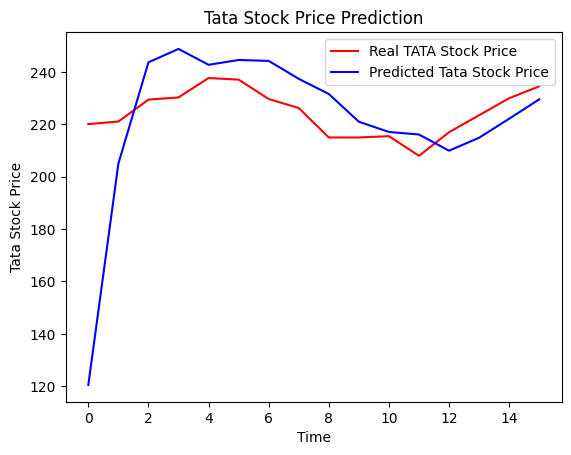

In [12]:
# Prediction on X Test Data
predicted_stock_price = model.predict(x_test)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)

# Visulizing The Results
plt.plot(real_stock_price, color='red', label='Real TATA Stock Price')
plt.plot(predicted_stock_price, color='blue', label = 'Predicted Tata Stock Price')
plt.title('Tata Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Tata Stock Price')
plt.legend()
plt.show()